In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets,layers,models
from tensorflow.keras.models import Sequential

In [ ]:
import cv2
import os
import PIL

In [ ]:
import tensorflow as tf

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    'flower_photos',
    origin=dataset_url,
    untar=True
)

print(data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
/root/.keras/datasets/flower_photos


In [ ]:
print(data_dir)

/root/.keras/datasets/flower_photos


In [ ]:
import os
os.listdir('/root/.keras/datasets/flower_photos')

['flower_photos']

In [ ]:
import os
os.listdir('/root/.keras/datasets/flower_photos/flower_photos')

['LICENSE.txt', 'dandelion', 'tulips', 'daisy', 'sunflowers', 'roses']

In [ ]:
import pathlib

data_dir = pathlib.Path("/root/.keras/datasets/flower_photos/flower_photos")

image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [ ]:
roses=list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2675221506_5286c0595f.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/7420699022_60fa574524_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/14019883858_e5d2a0ec10_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2777518561_105abc8cfc_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2300959680_8d22fa5ee2.jpg')]

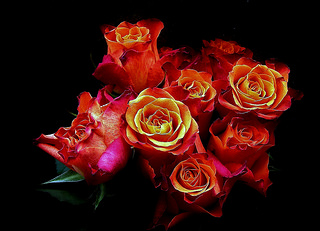

In [ ]:
PIL.Image.open(str(roses[2]))

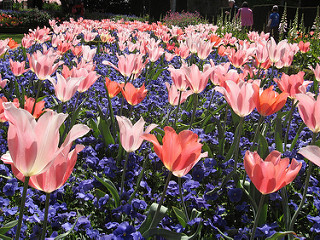

In [ ]:
tulips=list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[2]))

Read flowers images from disk into numpy array using openCV

In [ ]:
flowers_images_dict={
    'roses':list(data_dir.glob('roses/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflower/*')),
    'tulips':list(data_dir.glob('tulips/*')),
}

In [ ]:
flowers_labels_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [ ]:
flowers_images_dict['roses'][:5]

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2675221506_5286c0595f.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/7420699022_60fa574524_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/14019883858_e5d2a0ec10_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2777518561_105abc8cfc_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2300959680_8d22fa5ee2.jpg')]

In [ ]:
str(flowers_images_dict['roses'][0])

'/root/.keras/datasets/flower_photos/flower_photos/roses/2675221506_5286c0595f.jpg'

In [ ]:
img=cv2.imread(str(flowers_images_dict['roses'][0]))

In [ ]:
img.shape

(375, 500, 3)

In [ ]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [ ]:
X,y=[],[]
for flower_name, images in flowers_images_dict.items():
  for image in images:
    img=cv2.imread(str(image))
    resized_img=cv2.resize(img,(180,180))
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])


In [ ]:
X=np.array(X)
y=np.array(y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

In [ ]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

Build convolutional neural network and train it

In [ ]:
num_classes=5

model=Sequential([
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(num_classes)
])
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.fit(X_train_scaled,y_train,epochs=30)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 67s 925ms/step - accuracy: 0.4417 - loss: 1.2097
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 63s 894ms/step - accuracy: 0.6207 - loss: 0.9041
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 910ms/step - accuracy: 0.7217 - loss: 0.7061
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 64s 911ms/step - accuracy: 0.8182 - loss: 0.5004
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 63s 895ms/step - accuracy: 0.8779 - loss: 0.3466
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 82s 898ms/step - accuracy: 0.9331 - loss: 0.1997
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 82s 893ms/step - accuracy: 0.9699 - loss: 0.1095
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 910ms/step - accuracy: 0.9865 - loss: 0.0553
Epoch 9/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 921ms/step - accuracy: 0.9574 - loss: 0.1340
Epoch 10/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 65s 928ms/step - accuracy: 0.9897 - loss: 0.0476
Epoch 11/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 81s 910ms/step - accuracy: 0.9951 - loss: 0.0235
Epoch 12/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 83

In [ ]:
model.evaluate(X_test_scaled,y_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 0.6406 - loss: 2.0322


[2.0322062969207764, 0.6406460404396057]

here we can see that our training accuracy was 98 but where as our testing accuracy was just 64%

In [ ]:
predictions=model.predict(X_test_scaled)
predictions

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step


array([[  5.6045237 ,  -1.3006077 ,   7.291068  ,  -9.390383  ,
         -0.12774402],
       [  6.0996447 ,  16.064928  ,  -0.15678194, -19.48963   ,
          2.668862  ],
       [ 21.021097  ,   5.637757  ,   0.18235978, -23.932596  ,
          5.5198283 ],
       ...,
       [  2.2497044 ,   2.1235962 ,   4.411964  ,  -7.7917924 ,
          1.9055309 ],
       [  5.773026  ,  -2.0887663 ,   0.30263373, -12.61022   ,
         13.734652  ],
       [ 13.1043215 ,   6.0776916 ,  -8.820639  , -21.088133  ,
         14.783999  ]], dtype=float32)

In [ ]:
score=tf.nn.softmax(predictions[0])
np.argmax(score)

np.int64(2)

In [ ]:
y_test[0]

np.int64(2)

Improve test accuracy using data Agumentation

In [ ]:
img_height = 180
img_width = 180
data_agumentation=keras.Sequential([
    layers.RandomFlip("horizontal",input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


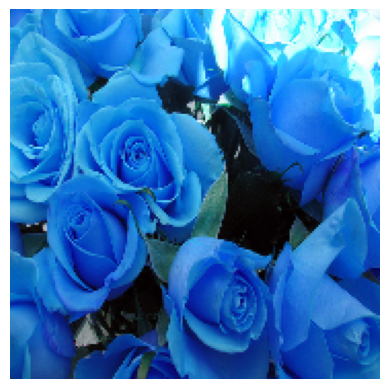

In [ ]:
plt.axis('off')
plt.imshow(X[0])

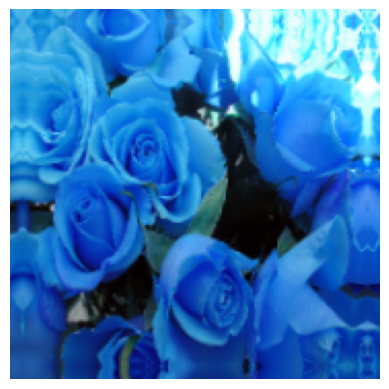

In [ ]:
plt.axis('off')
plt.imshow(data_agumentation(X)[0].numpy().astype("uint8"))

Train the model using data agumentation and drop out layer

In [ ]:
num_clasees=5
model=Sequential([
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(num_classes)
])
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.fit(X_train_scaled,y_train,epochs=10)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 67s 921ms/step - accuracy: 0.4538 - loss: 1.2371
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 82s 924ms/step - accuracy: 0.6113 - loss: 0.9356
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 85s 968ms/step - accuracy: 0.6818 - loss: 0.8025
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 65s 922ms/step - accuracy: 0.7513 - loss: 0.6364
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 82s 931ms/step - accuracy: 0.8321 - loss: 0.4646
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 65s 931ms/step - accuracy: 0.8793 - loss: 0.3361
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 66s 938ms/step - accuracy: 0.9286 - loss: 0.2168
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 65s 932ms/step - accuracy: 0.9596 - loss: 0.1239
Epoch 9/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 941ms/step - accuracy: 0.9749 - loss: 0.0933
Epoch 10/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 66s 943ms/step - accuracy: 0.9740 - loss: 0.0854


In [ ]:
model.evaluate(X_test_scaled,y_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.6676 - loss: 1.5420


[1.5420414209365845, 0.6675639152526855]